In [18]:
!pip install kagglehub 
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Show Elements

In [19]:
df.columns

Index(['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours',
       'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek',
       'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
       'EngagementLevel'],
      dtype='object')

# Random Forest Model traning using GridsearchCV with splited data (20% test set, 80% train set) and is balanced

In [20]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# =========================
# Features
# =========================
X = df[['Age', 'PlayTimeHours', 'SessionsPerWeek', 'AchievementsUnlocked', 'PlayerLevel', 'AvgSessionDurationMinutes']]
y = df['EngagementLevel']

# =========================
# One-Hot Encoding
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# Train / Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== Dataset Size ===")
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Total samples:", X.shape[0])

# ======================================================
# BASE MODEL（ bootstrap + OOB + balanced）
# ======================================================
model_s = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    bootstrap=True,
    oob_score=True,
    class_weight='balanced'
)

model_s.fit(X_train, y_train)

# OOB score
print("=== OOB Score ===")
print(model_s.oob_score_)

# =========================
# ROC_AUC score
# =========================
y_pred = model_s.predict(X_test)
y_proba = model_s.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='macro'
)

print("\n=== BASE MODEL RESULTS ===")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(model_s.get_params())
print(classification_report(y_test, y_pred))


# ======================================================
# GRID SEARCH
# ======================================================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [33], #not 32 not 34 so 33
    'min_samples_split': [2,3],
    'min_samples_leaf': [2,3], 
     'criterion': ['gini', 'entropy']
}

rf_base = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# =========================
# Best result
# =========================
model_s = grid_search.best_estimator_

print("\n=== BEST PARAMETERS ===")
print(grid_search.best_params_)

print("\n=== CV BEST SCORE (F1 Macro) ===")
print(grid_search.best_score_)

cv_scores = cross_val_score(
    model_s,         
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

print("\n=== CROSS VALIDATION (BEST MODEL) ===")
print(f"CV F1 Macro Mean: {cv_scores.mean():.4f}")
print(f"CV F1 Macro Std : {cv_scores.std():.4f}")

# =========================
# Final Evaluation
# =========================
y_pred_bal = model_s.predict(X_test)
y_proba_bal = model_s.predict_proba(X_test)

roc_auc_best = roc_auc_score(
    y_test,
    y_proba_bal,
    multi_class='ovr',
    average='macro'
)

print("\n=== FINAL MODEL RESULTS ===")
print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bal):.4f}")
print(classification_report(y_test, y_pred_bal))

=== Dataset Size ===
Train set size: 32027
Test set size: 8007
Total samples: 40034
=== OOB Score ===
0.9172573141411934

=== BASE MODEL RESULTS ===
ROC-AUC: 0.9421
Accuracy: 0.9164
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': True, 'random_state': 42, 'verbose': 0, 'warm_start': False}
              precision    recall  f1-score   support

        High       0.92      0.88      0.90      2067
         Low       0.91      0.89      0.90      2065
      Medium       0.92      0.95      0.93      3875

    accuracy                           0.92      8007
   macro avg       0.92      0.91      0.91      8007
weighted avg       0.92      0.92      0.92      8007


=== BEST PARAMETE

# Categorical Feature Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

# Clean column names (Prevents KeyError caused by hidden spaces)
df.columns = df.columns.str.strip()

#  features
selected_columns = [
    'Age', 'Gender', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 
    'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 
    'AchievementsUnlocked', 'Location', 'EngagementLevel'
]

# Extract data using .loc (Using your 'data' variable directly)
# If your variable is named 'data', do not use 'df'
df_final = df.loc[:, selected_columns].copy()

# Convert data types (This step is necessary for the model to process the data)
df_final['EngagementLevel'] = df_final['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_final['Gender'] = LabelEncoder().fit_transform(df_final['Gender'])
df_final = pd.get_dummies(df_final, columns=['Location', 'GameGenre'])

df_final.head(10)

,Age,Gender,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,1,16.271119,0,6,108,79,25,1,False,False,True,False,False,False,False,False,True
1,29,0,5.525961,0,5,144,11,10,1,False,False,False,True,False,False,False,False,True
2,22,0,8.223755,0,16,142,35,41,2,False,False,False,True,False,False,False,True,False
3,35,1,5.265351,1,9,85,57,47,1,False,False,False,True,True,False,False,False,False
4,33,1,15.531945,0,2,131,95,37,1,False,True,False,False,True,False,False,False,False
5,37,1,20.561855,0,2,81,74,22,0,False,True,False,False,False,True,False,False,False
6,25,1,9.752716,0,1,50,13,2,0,False,False,False,True,True,False,False,False,False
7,25,0,4.401729,0,10,48,27,23,1,True,False,False,False,False,True,False,False,False
8,38,0,18.152733,0,5,101,23,41,1,False,True,False,False,False,False,True,False,False
9,38,0,23.942772,0,13,95,99,36,2,False,False,True,False,False,False,False,True,False


# Feature Importance Analysis (Random Forest, train set)

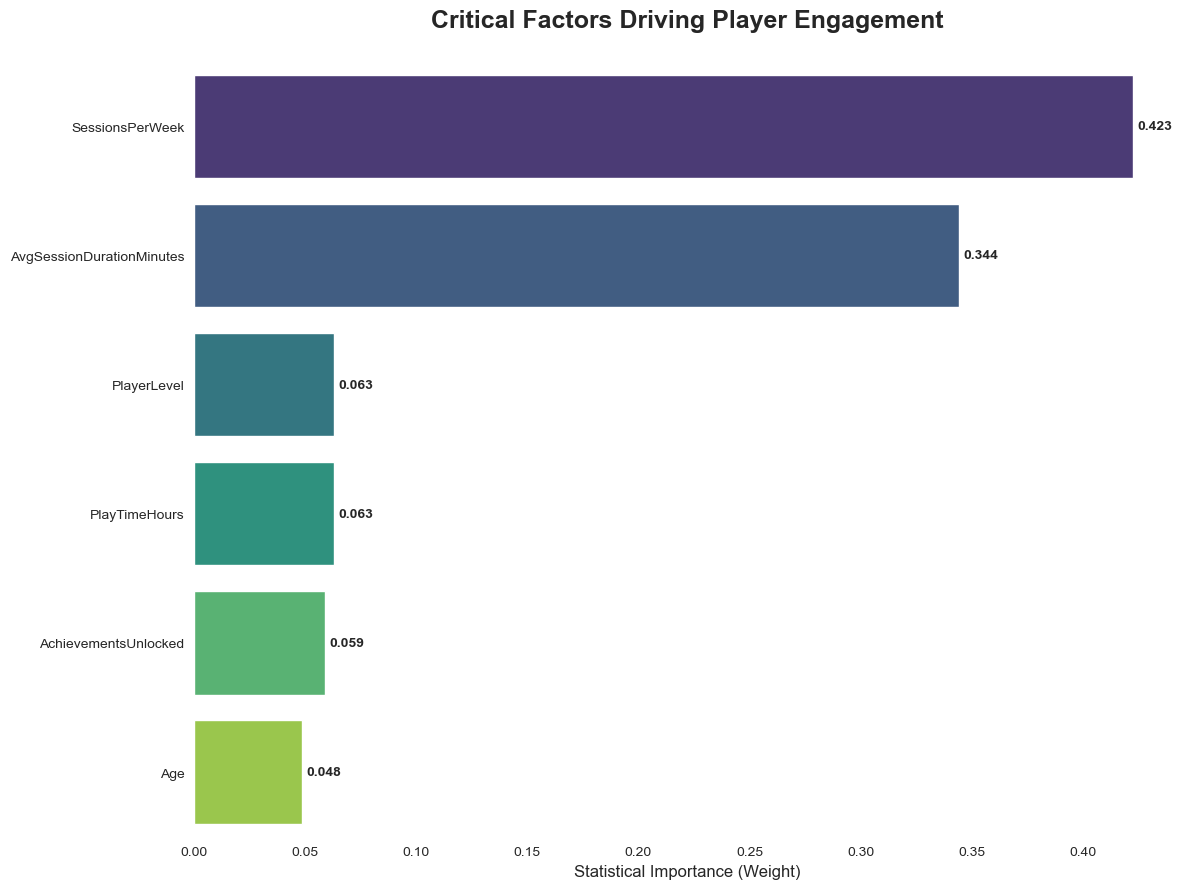

Total samples: 40034
Number of features: 6


In [22]:
importances = model_s.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- Plot Aesthetics ---
plt.figure(figsize=(12, 9)) # Slightly taller to prevent text crowding
sns.set_style("white") 

# Using the viridis gradient 
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# --- Add Precise Value Labels  ---
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002,  # Slight offset to the right
            p.get_y() + p.get_height()/2, 
            f'{width:.3f}', 
            va='center', fontsize=10, fontweight='bold')

# --- Title and Detail Optimization ---
plt.title('Critical Factors Driving Player Engagement', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Statistical Importance (Weight)', fontsize=12)
plt.ylabel('') # Hide Y-axis label to keep the visual clean
sns.despine(left=True, bottom=True) # Remove the outer frame

plt.tight_layout()
plt.show()
print(f"Total samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

# Confusion Matrix (on 20% test set)

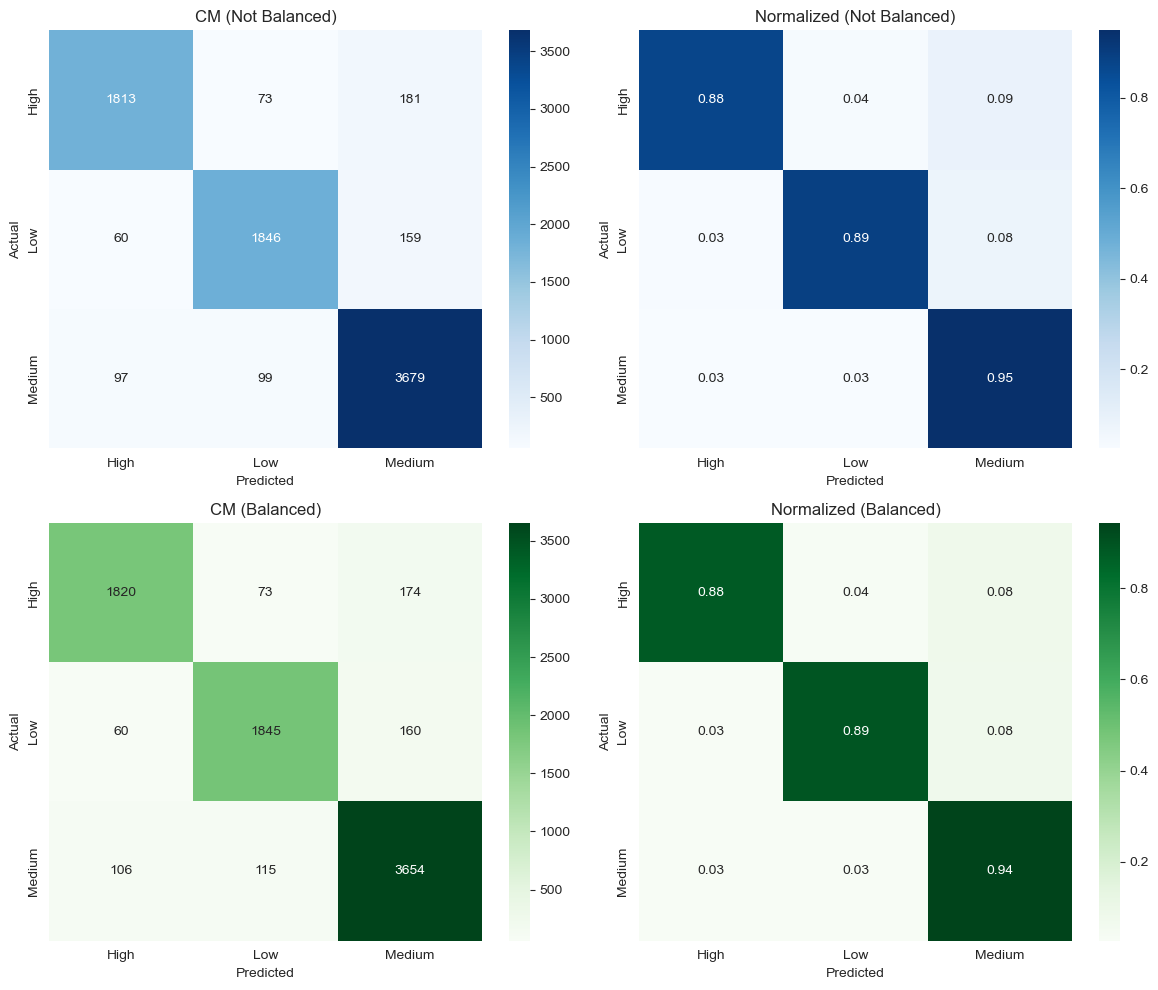

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Not balanced
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[0,0],
            xticklabels=model_s.classes_,
            yticklabels=model_s.classes_)
axes[0,0].set_title('CM (Not Balanced)')

sns.heatmap(confusion_matrix(y_test, y_pred, normalize='true'), annot=True, fmt='.2f',
            cmap='Blues', ax=axes[0,1],
            xticklabels=model_s.classes_,
            yticklabels=model_s.classes_)
axes[0,1].set_title('Normalized (Not Balanced)')

# Balanced
sns.heatmap(confusion_matrix(y_test, y_pred_bal), annot=True, fmt='d',
            cmap='Greens', ax=axes[1,0],
            xticklabels=model_s.classes_,
            yticklabels=model_s.classes_)
axes[1,0].set_title('CM (Balanced)')

sns.heatmap(confusion_matrix(y_test, y_pred_bal, normalize='true'), annot=True, fmt='.2f',
            cmap='Greens', ax=axes[1,1],
            xticklabels=model_s.classes_,
            yticklabels=model_s.classes_)
axes[1,1].set_title('Normalized (Balanced)')

for ax in axes.flat:
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Model Prediction Probabilities vs Actual Labels on Test Set

In [24]:
#y_proba = rf.predict_proba(X_test)

result_df = pd.DataFrame({
    'Actual': y_test.values
})

prob_df = pd.DataFrame(
    y_proba,
    columns=model_s.classes_
)

result_df = pd.concat([result_df, prob_df], axis=1)

print(result_df.head(100))

# categories
result_df['Predicted'] = result_df[model_s.classes_].idxmax(axis=1)

# Accuracy
accuracy = (result_df['Predicted'] == result_df['Actual']).mean()

print("Accuracy:", round(accuracy, 4))

    Actual  High   Low  Medium
0     High  0.05  0.03    0.92
1     High  0.05  0.88    0.07
2     High  0.91  0.02    0.07
3   Medium  0.11  0.03    0.86
4   Medium  0.02  0.31    0.67
..     ...   ...   ...     ...
95    High  0.88  0.06    0.06
96  Medium  0.03  0.08    0.89
97  Medium  0.07  0.02    0.91
98    High  0.89  0.03    0.08
99     Low  0.03  0.85    0.12

[100 rows x 4 columns]
Accuracy: 0.9164


## Random Forest Ensemble Structure trained on the training set (3 Individual Decision Trees)

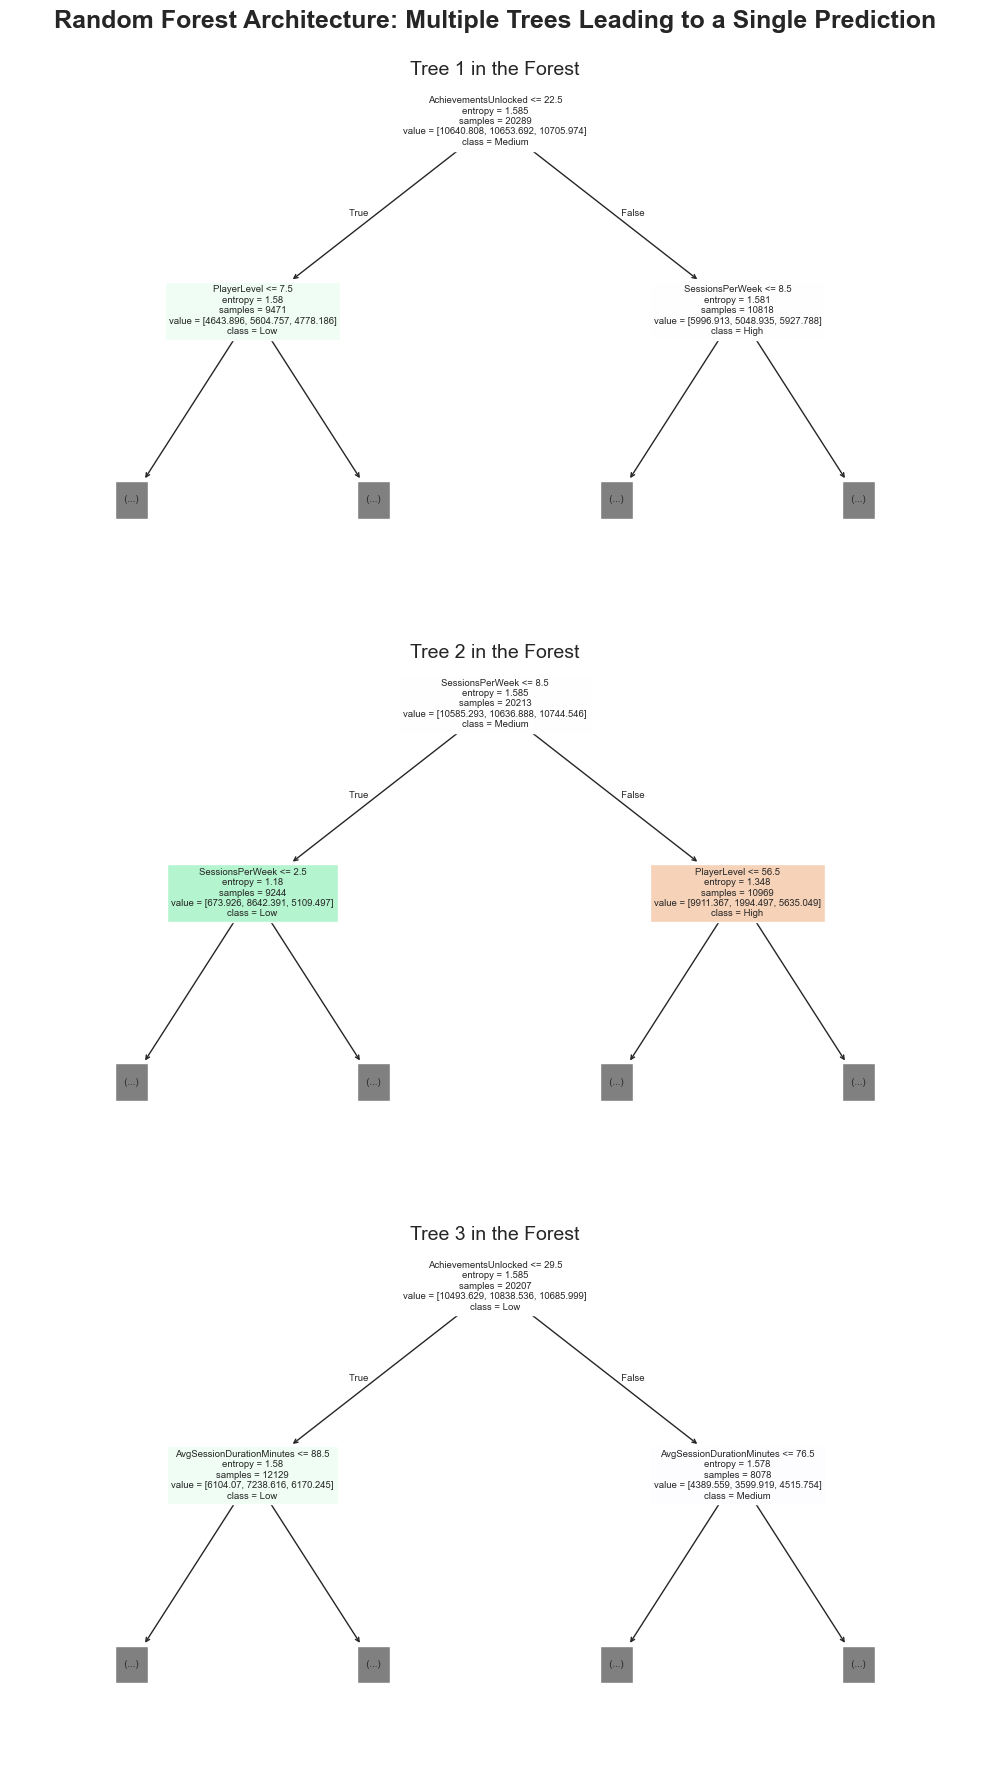

Total trees: 200


In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Visualize the first 3 trees to represent the 'Ensemble' (Bagging)
# This mimics the 'Decision Trees' row in your reference image
for i in range(3):
    plot_tree(
        model_s.estimators_[i],
        feature_names=X.columns,
        class_names=model_s.classes_,
        filled=True,
        max_depth=1,
        ax=axes[i]
    )
    axes[i].set_title(f'Tree {i+1} in the Forest', fontsize=14, y=0.9)

# Add an overall title describing the Bagging/Averaging process
plt.suptitle(
    'Random Forest Architecture: Multiple Trees Leading to a Single Prediction',
    fontsize=18, fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f"Total trees: {model_s.n_estimators}")

## Random Forest Model traning using GridsearchCV with full data (Gridsearch on full data, no test set)

In [26]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# =========================
# Features
# =========================
X = df[['Age', 'PlayTimeHours', 'SessionsPerWeek',
        'AchievementsUnlocked', 'PlayerLevel',
        'AvgSessionDurationMinutes']]

y = df['EngagementLevel']

# Optional (only needed if categorical exists)
X = pd.get_dummies(X, drop_first=True)

# =========================
# Model (FIXED: OOB here)
# =========================
rf_base_f = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    class_weight='balanced',
    oob_score=True   
)

# =========================
# Grid Search
# =========================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [2, 4]
}

grid = GridSearchCV(
    estimator=rf_base_f ,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    return_train_score=True,
    n_jobs=-1
)

grid.fit(X, y)

results = pd.DataFrame(grid.cv_results_)

results['overfit_gap'] = (
    results['mean_train_score'] - results['mean_test_score']
)

best_index = grid.best_index_

print("Best Params:")
print(grid.best_params_)

print("\nMean Train Score (CV):")
print(results.loc[best_index, 'mean_train_score'])

print("Mean Test Score (CV):")
print(results.loc[best_index, 'mean_test_score'])

print("Overfitting Gap:")
print(results.loc[best_index, 'overfit_gap'])

# =========================
# Best Model
# =========================
model_f = grid.best_estimator_

print("\n=== OOB SCORE ===")
print(model_f.oob_score_)

# =========================
# FINAL EVALUATION (TRAINING SET - OPTIMISTIC)
# =========================
y_pred = model_f.predict(X)
##y_proba = best_model.predict_proba(X)
from sklearn.model_selection import cross_val_predict

y_proba = cross_val_predict(
    model_f, X, y,
    cv=5,
    method='predict_proba'
)

roc_auc_score(y, y_proba, multi_class='ovr', average='macro')

accuracy = accuracy_score(y, y_pred)


print("\n=== FINAL MODEL RESULTS (TRAINING DATA - OPTIMISTIC) ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(classification_report(y, y_pred))

Best Params:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Mean Train Score (CV):
0.9444894411260387
Mean Test Score (CV):
0.9139931121328715
Overfitting Gap:
0.030496328993167232

=== OOB SCORE ===
0.9176200229804666

=== FINAL MODEL RESULTS (TRAINING DATA - OPTIMISTIC) ===
Accuracy: 0.9476
ROC-AUC: 0.9421
              precision    recall  f1-score   support

        High       0.94      0.93      0.93     10336
         Low       0.94      0.93      0.94     10324
      Medium       0.95      0.97      0.96     19374

    accuracy                           0.95     40034
   macro avg       0.95      0.94      0.94     40034
weighted avg       0.95      0.95      0.95     40034



# Confusion Matrix (full data)

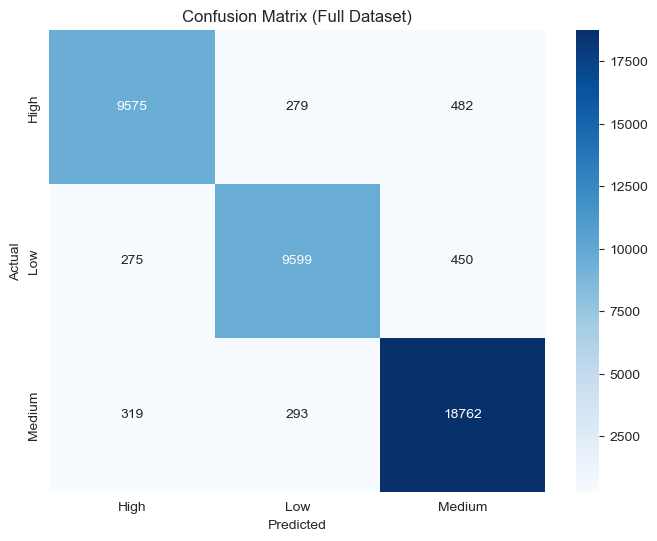

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Prediction
# =========================
y_all_pred = model_f.predict(X)

# =========================
# Confusion matrix
# =========================
cm_full = confusion_matrix(y, y_all_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_full,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model_f.classes_,
    yticklabels=model_f.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Full Dataset)")
plt.show()

# Model Prediction Probabilities vs Actual Labels on full data

In [30]:
# =========================
# Predict probabilities (FULL DATA)
# =========================
probabilities = model_f.predict_proba(X)

# =========================
# Create result dataframe
# =========================
result_df = pd.DataFrame({
    'Actual': y.values
})

prob_df = pd.DataFrame(
    probabilities,
    columns=model_f.classes_
)

result_df = pd.concat([result_df, prob_df], axis=1)

print(result_df.head(100))

# =========================
# Predicted class (max probability)
# =========================
result_df['Predicted'] = result_df[model_f.classes_].idxmax(axis=1)

# =========================
# Accuracy
# =========================
accuracy = (result_df['Predicted'] == result_df['Actual']).mean()

print("Accuracy (Full Data):", round(accuracy, 4))

    Actual      High       Low    Medium
0   Medium  0.043553  0.019624  0.936824
1   Medium  0.033793  0.023123  0.943084
2     High  0.961464  0.032598  0.005938
3   Medium  0.049354  0.031000  0.919647
4   Medium  0.022520  0.037041  0.940438
..     ...       ...       ...       ...
95    High  0.968235  0.008598  0.023167
96     Low  0.000000  0.988907  0.011093
97  Medium  0.008683  0.161282  0.830035
98  Medium  0.040374  0.019932  0.939694
99    High  0.715543  0.021516  0.262941

[100 rows x 4 columns]
Accuracy (Full Data): 0.9476


## Random Forest Ensemble Structure trained on full data set (3 Individual Decision Trees)

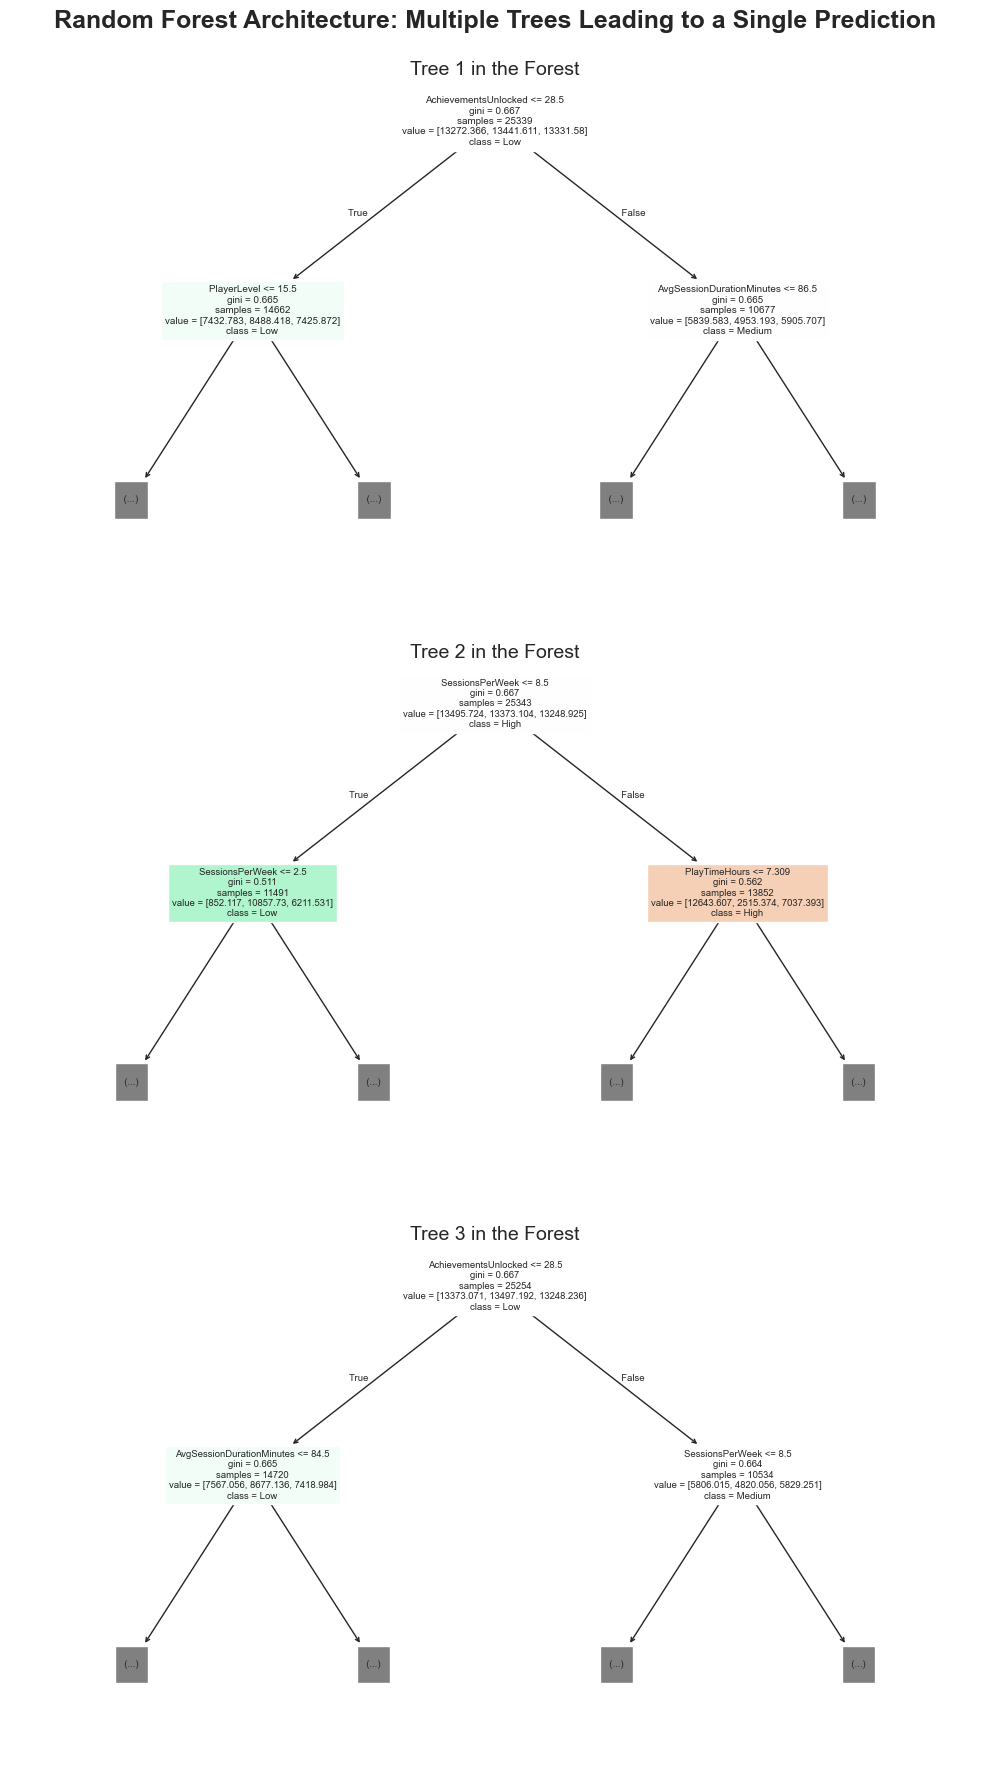

Total trees: 100


In [31]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 18))

for i in range(3):
    plot_tree(
        model_f.estimators_[i],
        feature_names=X.columns,
        class_names=model_f.classes_,
        filled=True,
        max_depth=1,
        ax=axes[i]
    )
    axes[i].set_title(f'Tree {i+1} in the Forest', fontsize=14, y=0.9)

plt.suptitle(
    'Random Forest Architecture: Multiple Trees Leading to a Single Prediction',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f"Total trees: {model_f.n_estimators}")

# Feature Importance Analysis (Random Forest, full data set)

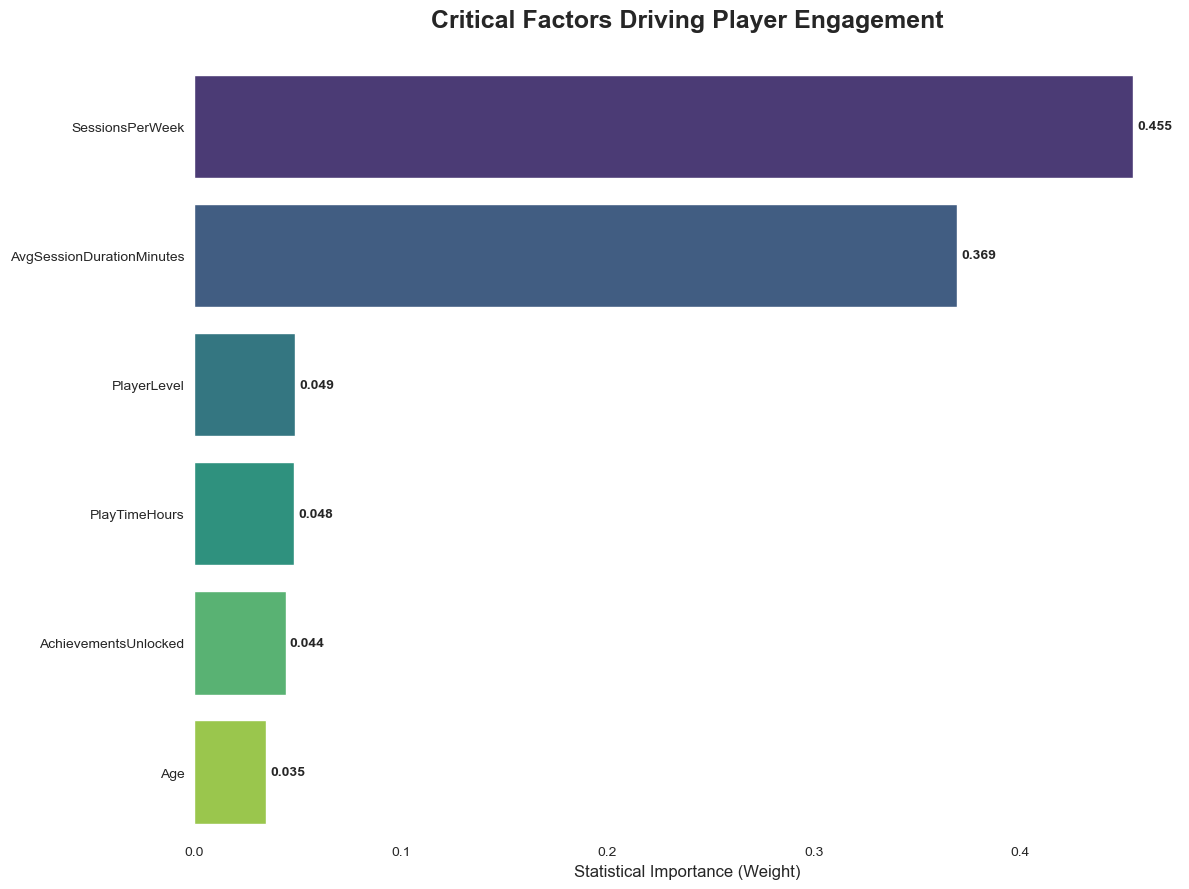

Total samples: 40034
Number of features: 6


In [32]:
importances = model_f.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- Plot Aesthetics ---
plt.figure(figsize=(12, 9)) # Slightly taller to prevent text crowding
sns.set_style("white") 

# Using the viridis gradient for a high-end professional look
ax = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# --- Add Precise Value Labels---
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002,  # Slight offset to the right
            p.get_y() + p.get_height()/2, 
            f'{width:.3f}', 
            va='center', fontsize=10, fontweight='bold')

# --- Title and Detail Optimization ---
plt.title('Critical Factors Driving Player Engagement', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Statistical Importance (Weight)', fontsize=12)
plt.ylabel('') # Hide Y-axis label to keep the visual clean
sns.despine(left=True, bottom=True) # Remove the outer frame

plt.tight_layout()
plt.show()
print(f"Total samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

# Permutation Feature Importance

                     Feature  Importance_Mean  Importance_STD
2            SessionsPerWeek         0.472915        0.001318
5  AvgSessionDurationMinutes         0.388183        0.001952
3       AchievementsUnlocked         0.052723        0.000537
4                PlayerLevel         0.050820        0.000722
1              PlayTimeHours         0.014689        0.000206
0                        Age         0.013341        0.000186


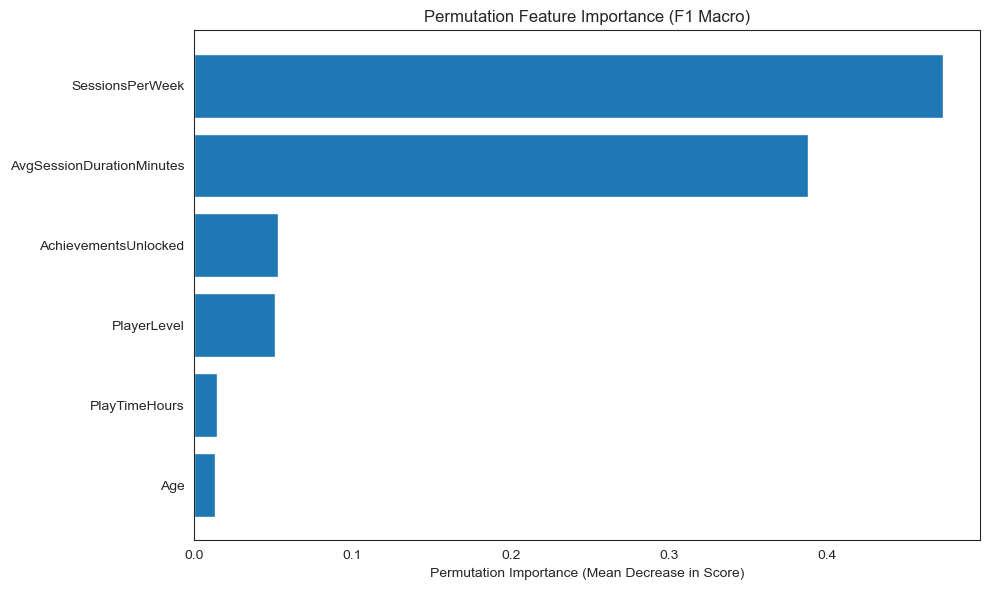

In [33]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# Permutation Importance
# =========================
result = permutation_importance(
    model_f,      
    X,           
    y,            
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',   
    n_jobs=-1
)

# =========================
# tidup result
# =========================
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_STD': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print(importances)

# =========================
# show
# =========================
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][::-1], importances['Importance_Mean'][::-1])
plt.xlabel("Permutation Importance (Mean Decrease in Score)")
plt.title("Permutation Feature Importance (F1 Macro)")
plt.tight_layout()
plt.show()

## Permutation Feature Importance normalized into a percentage contribution

In [34]:
import pandas as pd

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

# abs
importances['Importance'] = importances['Importance'].abs()

# proposion
importances['Importance_%'] = (
    importances['Importance'] / importances['Importance'].sum()
) * 100

importances = importances.sort_values('Importance_%', ascending=False)

print(importances)


                     Feature  Importance  Importance_%
2            SessionsPerWeek    0.472915     47.640677
5  AvgSessionDurationMinutes    0.388183     39.104927
3       AchievementsUnlocked    0.052723      5.311193
4                PlayerLevel    0.050820      5.119488
1              PlayTimeHours    0.014689      1.479794
0                        Age    0.013341      1.343921


# Download model

In [35]:
import joblib

model_f = grid.best_estimator_
joblib.dump(model_f, "rf.joblib", compress=3)

['rf.joblib']